In [10]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from torch_geometric.utils import degree

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

DATA_PROCESSED = Path("../data/processed")

## 1️. Load Processed Graph Datasets



In [2]:
def load_graph(name):
    path = DATA_PROCESSED / f"{name}_final.pt"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found.")
    data = torch.load(path, weights_only=False)
    print(f"Loaded {name}")
    print(data)
    return data

# Change dataset name here: "paysim", "elliptic", "synthetic"
dataset_name = "paysim"

data = load_graph(dataset_name)

Loaded paysim
Data(x=[592288, 8], edge_index=[2, 325933], y=[592288], num_nodes=592288, train_mask=[592288], val_mask=[592288], test_mask=[592288])


## 2️. Manual Message Passing (From Scratch)


In [3]:
def build_adjacency(edge_index, num_nodes, mode="directed"):
    adj = torch.zeros((num_nodes, num_nodes))

    src, dst = edge_index

    if mode == "directed":
        adj[src, dst] = 1

    elif mode == "undirected":
        adj[src, dst] = 1
        adj[dst, src] = 1

    elif mode == "reversed":
        adj[dst, src] = 1

    return adj

## 3️. Feature Diffusion Study


In [7]:
def propagate_features(data, mode="directed"):
    src, dst = data.edge_index

    if mode == "undirected":
        src = torch.cat([src, dst])
        dst = torch.cat([dst, src[:len(dst)]])
    elif mode == "reversed":
        src, dst = dst, src

    num_nodes = data.num_nodes
    x = data.x

    # Compute degrees
    deg = torch.zeros(num_nodes)
    deg.scatter_add_(0, dst, torch.ones_like(dst, dtype=torch.float))

    deg[deg == 0] = 1

    # Aggregate messages
    aggregated = torch.zeros_like(x)
    aggregated.index_add_(0, dst, x[src])

    # Normalize
    aggregated = aggregated / deg.unsqueeze(1)

    return aggregated

## 4️. Compare Aggregation Modes


In [8]:
def evaluate_features(features, data):
    X_train = features[data.train_mask].numpy()
    y_train = data.y[data.train_mask].numpy()

    X_test = features[data.test_mask].numpy()
    y_test = data.y[data.test_mask].numpy()

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    results = {
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }

    return results

In [ ]:
results = {}

# Raw features
results["Raw"] = evaluate_features(data.x, data)

# Directed
directed_feats = propagate_features(data, mode="directed")
results["Directed"] = evaluate_features(directed_feats, data)

# Undirected
undirected_feats = propagate_features(data, mode="undirected")
results["Undirected"] = evaluate_features(undirected_feats, data)

# Reversed
reversed_feats = propagate_features(data, mode="reversed")
results["Reversed"] = evaluate_features(reversed_feats, data)

## 5️. Result Visualization


In [12]:
df_results = pd.DataFrame(results).T
df_results

,F1,Precision,Recall,ROC-AUC
Raw,0.136927,0.599057,0.077298,0.880972
Directed,0.000000,0.000000,0.000000,0.727522
Undirected,0.148467,0.638889,0.083993,0.872438
Reversed,0.147391,0.634259,0.083384,0.873154


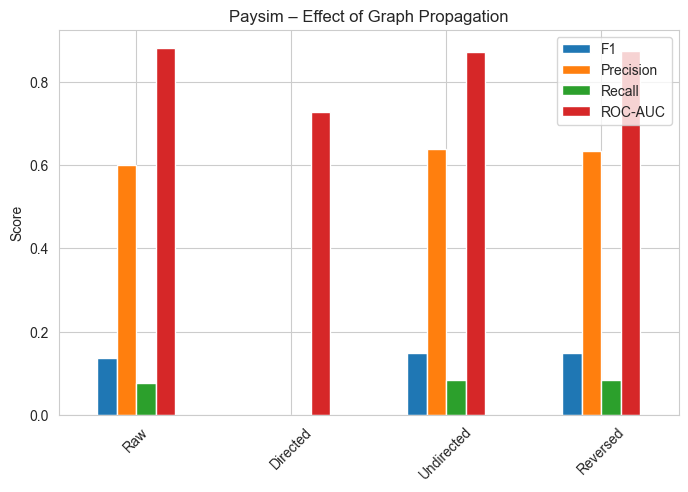

In [13]:
df_results.plot(kind="bar")
plt.title(f"{dataset_name.capitalize()} – Effect of Graph Propagation")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()